# depth-pose-boxing — 3D Skeleton Visualisation

Inspect the normalised (T, 9, 3) skeleton output from `main.py`.

**What this notebook shows:**
1. 3D skeleton for a single frame — all 9 joints with bones
2. Wrist trajectories over time — punch motion in X, Y, Z
3. Joint position table — raw XYZ numbers for the first 5 frames

In [1]:
import sys
sys.path.append('..')  # allow imports from project root

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from src.constants import (
    ACTIVE_JOINT_NAMES,
    SKELETON_EDGES,
    BOXING_JOINTS,
    NUM_ACTIVE_JOINTS,
)

# ── Load your .npy file ───────────────────────────────────────────────
# Change this path to your processed output
NPY_PATH = '../data/processed/no_hardware/test/test_video_pose_norm.npy'

sequence = np.load(NPY_PATH)   # (T, 9, 3)
T = sequence.shape[0]

print(f'Loaded: {NPY_PATH}')
print(f'Shape : {sequence.shape}  →  {T} frames, {NUM_ACTIVE_JOINTS} joints, 3 axes (X Y Z)')
print(f'X range: [{sequence[:,:,0].min():.3f}, {sequence[:,:,0].max():.3f}]')
print(f'Y range: [{sequence[:,:,1].min():.3f}, {sequence[:,:,1].max():.3f}]')
print(f'Z range: [{sequence[:,:,2].min():.3f}, {sequence[:,:,2].max():.3f}]')

Loaded: ../data/processed/no_hardware/test/test_video_pose_norm.npy
Shape : (705, 9, 3)  →  705 frames, 9 joints, 3 axes (X Y Z)
X range: [-0.540, 0.730]
Y range: [-0.123, 1.093]
Z range: [-0.548, 0.650]


In [2]:
# Camera-relative (pre-normalisation) output
CAMERA_NPY_PATH = '../data/processed/no_hardware/test/test_video_camera.npy'
camera_seq = np.load(CAMERA_NPY_PATH)  # (T, 9, 3) in camera space
camera_T = camera_seq.shape[0]
print(f'Camera file: {CAMERA_NPY_PATH}')
print(f'Shape      : {camera_seq.shape}  ->  {camera_T} frames, {NUM_ACTIVE_JOINTS} joints, 3 axes (X Y Z)')
print(f'X range    : [{camera_seq[:,:,0].min():.3f}, {camera_seq[:,:,0].max():.3f}]')
print(f'Y range    : [{camera_seq[:,:,1].min():.3f}, {camera_seq[:,:,1].max():.3f}]')
print(f'Z range    : [{camera_seq[:,:,2].min():.3f}, {camera_seq[:,:,2].max():.3f}]')

Camera file: ../data/processed/no_hardware/test/test_video_camera.npy
Shape      : (705, 9, 3)  ->  705 frames, 9 joints, 3 axes (X Y Z)
X range    : [-0.606, 0.697]
Y range    : [-0.484, 0.842]
Z range    : [1.205, 2.601]


## Cell 1 — 3D Skeleton (single frame)

All 9 joints plotted in 3D space. Rotate interactively with your mouse.

- 🔴 Red — wrists (punch endpoints)
- 🔵 Blue — shoulders
- 🟢 Green — hips
- ⚪ White — nose

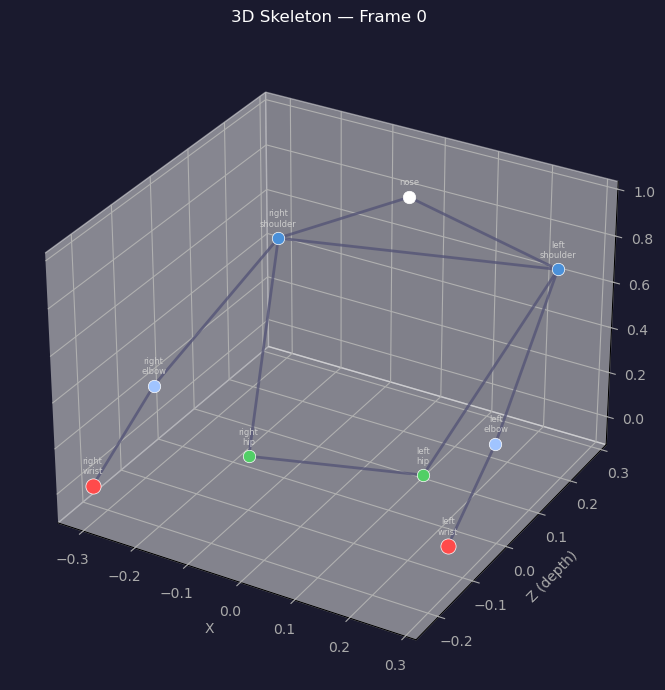

In [3]:
# Change this to inspect a different frame
FRAME_IDX = 0

# Colour map — local joint index → colour
JOINT_COLOURS = {
    0: 'white',    # nose
    1: '#4A90D9',  # left_shoulder  — blue
    2: '#4A90D9',  # right_shoulder — blue
    3: '#A0C4FF',  # left_elbow     — light blue
    4: '#A0C4FF',  # right_elbow    — light blue
    5: '#FF4B4B',  # left_wrist     — red
    6: '#FF4B4B',  # right_wrist    — red
    7: '#51CF66',  # left_hip       — green
    8: '#51CF66',  # right_hip      — green
}

frame = sequence[FRAME_IDX]   # (9, 3)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

# Draw bones
for (i, j) in SKELETON_EDGES:
    xs = [frame[i, 0], frame[j, 0]]
    ys = [frame[i, 1], frame[j, 1]]
    zs = [frame[i, 2], frame[j, 2]]
    ax.plot(xs, zs, ys, color='#555577', linewidth=2, alpha=0.8)

# Draw joints
for j in range(NUM_ACTIVE_JOINTS):
    x, y, z = frame[j]
    colour   = JOINT_COLOURS[j]
    size     = 120 if j in [5, 6] else 80  # wrists larger
    ax.scatter(x, z, y, c=colour, s=size, zorder=5,
               edgecolors='white', linewidths=0.5)
    ax.text(x, z, y + 0.05,
            ACTIVE_JOINT_NAMES[j].replace('_', '\n'),
            fontsize=6, color='#cccccc', ha='center')

ax.set_xlabel('X', color='#aaaaaa')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.set_zlabel('Y', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.set_title(f'3D Skeleton — Frame {FRAME_IDX}', color='white', pad=15)

plt.tight_layout()
plt.show()

## Cell 2 — Wrist Trajectories Over Time

X, Y, Z position of both wrists across all frames.
Punch delivery shows as a sharp spike in X or Z.

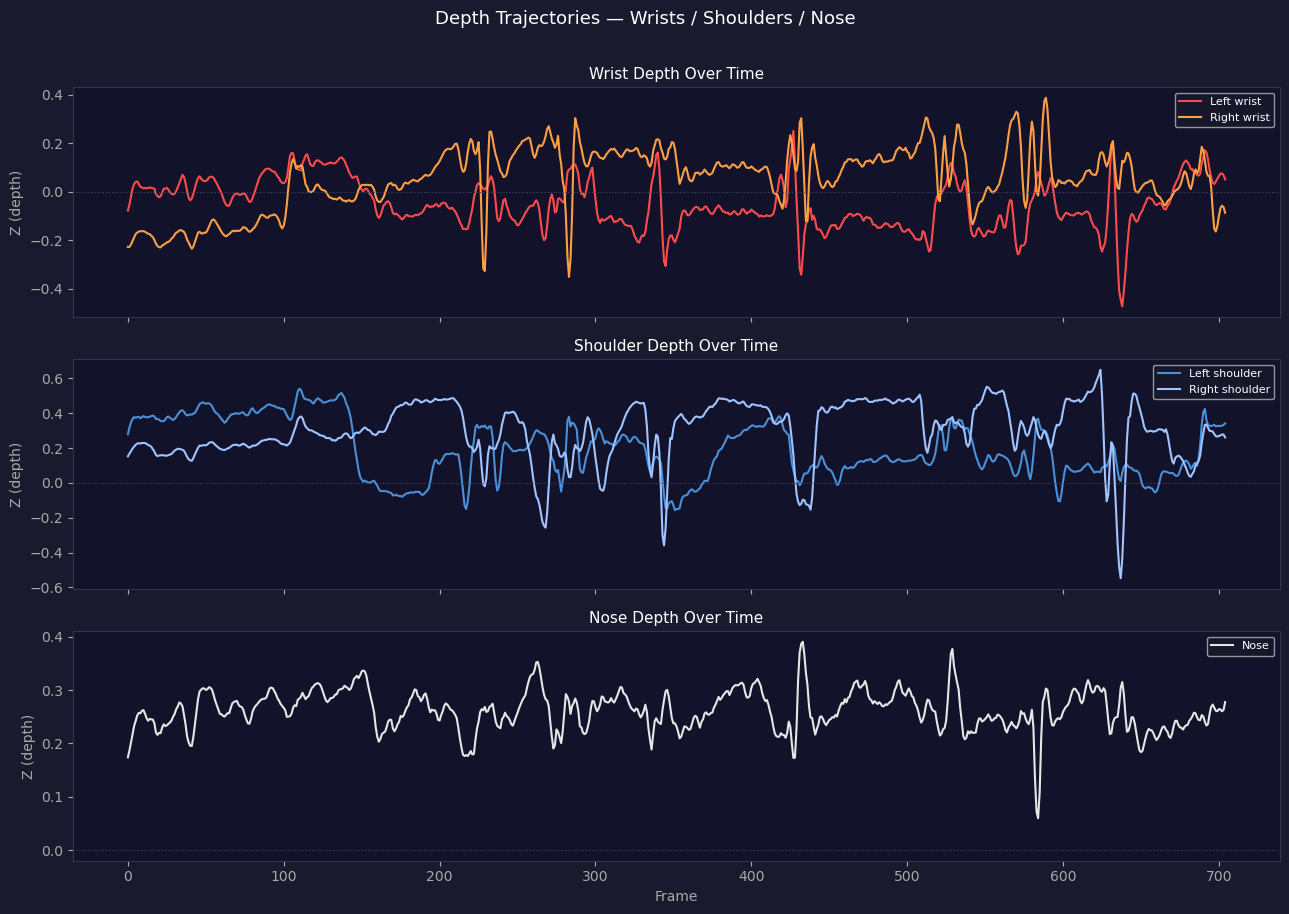

In [4]:
# Local joint indices
NOSE = 0
L_WRIST = 5
R_WRIST = 6
L_SHOULDER = 1
R_SHOULDER = 2

frames = np.arange(T)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.patch.set_facecolor('#1a1a2e')

colours = {
    'left_wrist':    '#FF4B4B',
    'right_wrist':   '#FF9F43',
    'left_shoulder': '#4A90D9',
    'right_shoulder':'#A0C4FF',
    'nose':          '#E6E6E6',
}

# 1) Wrist depth (Z)
ax = axes[0]
ax.set_facecolor('#12122a')
ax.plot(frames, sequence[:, L_WRIST, 2],
        color=colours['left_wrist'], linewidth=1.5, label='Left wrist')
ax.plot(frames, sequence[:, R_WRIST, 2],
        color=colours['right_wrist'], linewidth=1.5, label='Right wrist')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Wrist Depth Over Time', color='white', fontsize=11)

# 2) Shoulder depth (Z)
ax = axes[1]
ax.set_facecolor('#12122a')
ax.plot(frames, sequence[:, L_SHOULDER, 2],
        color=colours['left_shoulder'], linewidth=1.5, label='Left shoulder')
ax.plot(frames, sequence[:, R_SHOULDER, 2],
        color=colours['right_shoulder'], linewidth=1.5, label='Right shoulder')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Shoulder Depth Over Time', color='white', fontsize=11)

# 3) Nose depth (Z)
ax = axes[2]
ax.set_facecolor('#12122a')
ax.plot(frames, sequence[:, NOSE, 2],
        color=colours['nose'], linewidth=1.5, label='Nose')
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8,
          facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Nose Depth Over Time', color='white', fontsize=11)

axes[-1].set_xlabel('Frame', color='#aaaaaa')
fig.suptitle('Depth Trajectories — Wrists / Shoulders / Nose',
             color='white', fontsize=13, y=1.01)

plt.tight_layout()
plt.show()

## Cell 2B — Camera-Relative Trajectories
Same plots as Cell 2, but using the camera-space sequence (_camera.npy).

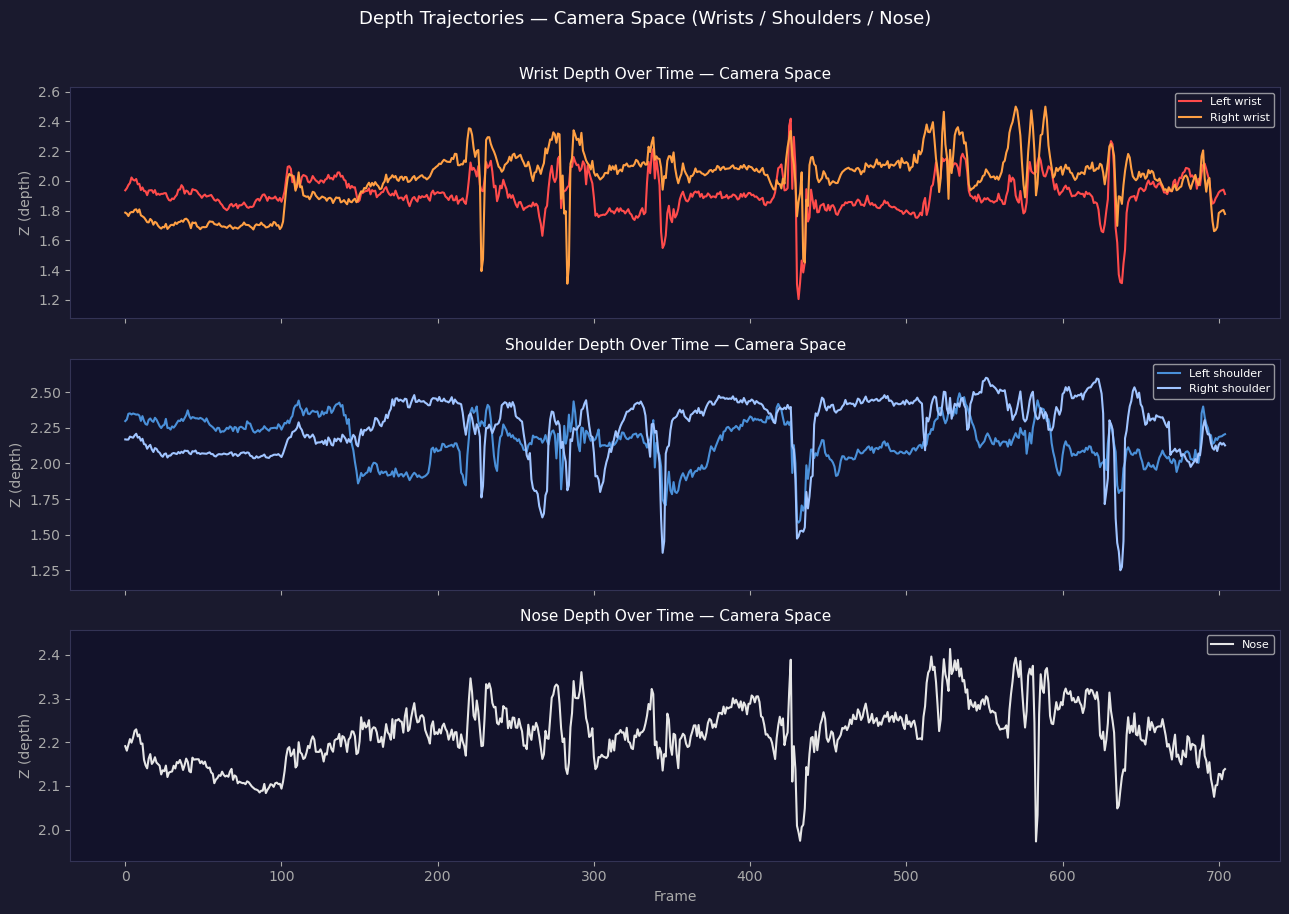

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper for Auto-Scaling with Padding ---
def get_padded_limits(data_arrays, padding=0.1):
    """Calculates min/max across multiple arrays and adds a % padding."""
    # Flatten/combine arrays to find global min/max for that specific subplot
    combined = np.concatenate([arr.flatten() for arr in data_arrays])
    d_min, d_max = np.min(combined), np.max(combined)
    diff = d_max - d_min
    
    # Handle edge case where data is a flat line
    if diff == 0: 
        return d_min - 1, d_max + 1
        
    return d_min - (diff * padding), d_max + (diff * padding)

frames_cam = np.arange(camera_T)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.patch.set_facecolor('#1a1a2e')

# 1) Wrist depth (Z)
ax = axes[0]
ax.set_facecolor('#12122a')
l_wrist_data = camera_seq[:, L_WRIST, 2]
r_wrist_data = camera_seq[:, R_WRIST, 2]
ax.plot(frames_cam, l_wrist_data, color=colours['left_wrist'], linewidth=1.5, label='Left wrist')
ax.plot(frames_cam, r_wrist_data, color=colours['right_wrist'], linewidth=1.5, label='Right wrist')
ax.set_ylim(get_padded_limits([l_wrist_data, r_wrist_data])) # <--- Applied here
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8, facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Wrist Depth Over Time — Camera Space', color='white', fontsize=11)

# 2) Shoulder depth (Z)
ax = axes[1]
ax.set_facecolor('#12122a')
l_sh_data = camera_seq[:, L_SHOULDER, 2]
r_sh_data = camera_seq[:, R_SHOULDER, 2]
ax.plot(frames_cam, l_sh_data, color=colours['left_shoulder'], linewidth=1.5, label='Left shoulder')
ax.plot(frames_cam, r_sh_data, color=colours['right_shoulder'], linewidth=1.5, label='Right shoulder')
ax.set_ylim(get_padded_limits([l_sh_data, r_sh_data])) # <--- Applied here
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8, facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Shoulder Depth Over Time — Camera Space', color='white', fontsize=11)

# 3) Nose depth (Z)
ax = axes[2]
ax.set_facecolor('#12122a')
nose_data = camera_seq[:, NOSE, 2]
ax.plot(frames_cam, nose_data, color=colours['nose'], linewidth=1.5, label='Nose')
ax.set_ylim(get_padded_limits([nose_data])) # <--- Applied here
ax.set_ylabel('Z (depth)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.axhline(0, color='#444466', linewidth=0.8, linestyle=':')
ax.legend(loc='upper right', fontsize=8, facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
ax.set_title('Nose Depth Over Time — Camera Space', color='white', fontsize=11)

axes[-1].set_xlabel('Frame', color='#aaaaaa')
fig.suptitle('Depth Trajectories — Camera Space (Wrists / Shoulders / Nose)',
             color='white', fontsize=13, y=1.01)

plt.tight_layout()
plt.show()

## Cell 3 — Joint Position Table

Raw XYZ coordinates for the first 5 frames.
Confirms the numbers are real and the pipeline ran correctly.

In [6]:
N_FRAMES = 5   # change to inspect more frames

# Header
col_w  = 10
header = f"{'Joint':<18}" + "".join(
    [f"{'Frame '+str(i):>{col_w*3}}" for i in range(N_FRAMES)]
)
subhdr = f"{'':18}" + "".join(
    [f"{'X':>{col_w}}{'Y':>{col_w}}{'Z':>{col_w}}" for _ in range(N_FRAMES)]
)

print(header)
print(subhdr)
print('-' * (18 + col_w * 3 * N_FRAMES))

for j in range(NUM_ACTIVE_JOINTS):
    name    = ACTIVE_JOINT_NAMES[j]
    marker  = ' ◀' if j in [5, 6] else ''   # highlight wrists
    row     = f"{name + marker:<18}"
    for t in range(N_FRAMES):
        x, y, z = sequence[t, j]
        row += f"{x:>{col_w}.3f}{y:>{col_w}.3f}{z:>{col_w}.3f}"
    print(row)

print('-' * (18 + col_w * 3 * N_FRAMES))
print(f'\nTotal frames in sequence: {T}')
print(f'Output shape: {sequence.shape}  →  (T, 9 joints, 3 axes)')

Joint                                    Frame 0                       Frame 1                       Frame 2                       Frame 3                       Frame 4
                           X         Y         Z         X         Y         Z         X         Y         Z         X         Y         Z         X         Y         Z
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
nose                   0.022     0.959     0.174     0.013     0.952     0.187     0.006     0.951     0.202     0.000     0.953     0.217    -0.003     0.952     0.233
left_shoulder          0.237     0.650     0.279     0.228     0.646     0.319     0.220     0.650     0.348     0.215     0.658     0.367     0.214     0.662     0.378
right_shoulder        -0.213     0.664     0.153    -0.221     0.661     0.167    -0.231     0.663     0.183    -0.240     0.666     0.198    -0.244     0.

## Cell 4 — Kinematics (.npz) Preview

Load and inspect the kinematics file, then expose elbow angles for plotting.

In [7]:
# Load kinematics file and expose elbow angles for the plot below
KINEMATICS_PATH = '../data/processed/no_hardware/test/test_video_kinematics.npz'

kin = np.load(KINEMATICS_PATH, allow_pickle=True)
print(f'Kinematics file: {KINEMATICS_PATH}')
print('Keys:', list(kin.files))

def _preview_array(name, arr, max_rows=3):
    arr = np.asarray(arr)
    print(f'  - {name}: shape={arr.shape}, dtype={arr.dtype}')
    if arr.size == 0:
        return
    flat = arr.reshape(-1, *arr.shape[arr.ndim - 1:])
    print('    sample:', flat[:max_rows])

print('Preview:')
for key in kin.files:
    _preview_array(key, kin[key])

# Try to find elbow angles in the npz
def _find_elbow_angles(npz_obj):
    preferred = [
        'elbow_angle_deg',
        'elbow_angles_deg',
        'elbow_angle',
        'elbow_angles',
    ]
    for name in preferred:
        if name in npz_obj.files:
            return npz_obj[name], name
    for name in npz_obj.files:
        if 'elbow' in name.lower() and 'angle' in name.lower():
            return npz_obj[name], name
    return None, None

elbow_angle_raw, elbow_key = _find_elbow_angles(kin)
if elbow_angle_raw is None:
    elbow_angle_deg = None
    print('No elbow angle array found in this file.')
else:
    elbow_angle_raw = np.asarray(elbow_angle_raw)
    if elbow_angle_raw.ndim == 1:
        elbow_angle_raw = elbow_angle_raw.reshape(-1, 1)
    # Convert to degrees if values look like radians
    if np.nanmax(np.abs(elbow_angle_raw)) <= (2 * np.pi + 0.1):
        elbow_angle_deg = np.degrees(elbow_angle_raw)
        unit = 'deg (converted from rad)'
    else:
        elbow_angle_deg = elbow_angle_raw
        unit = 'deg'
    frames = np.arange(elbow_angle_deg.shape[0])
    print(f'Using {elbow_key} as elbow angles ({unit}). Shape: {elbow_angle_deg.shape}')

Kinematics file: ../data/processed/no_hardware/test/test_video_kinematics.npz
Keys: ['velocity_3d', 'acceleration_3d', 'elbow_angle_deg']
Preview:
  - velocity_3d: shape=(705, 2, 3), dtype=float32
    sample: [[ 0.982567    1.0504123   0.6773069 ]
 [ 0.7288961  -0.6575115  -1.1990249 ]
 [ 1.3809537   0.67793053  1.0913256 ]]
  - acceleration_3d: shape=(705, 2, 3), dtype=float32
    sample: [[ 13.635049  -11.491255   16.382479 ]
 [ -7.6871758  12.858699   27.928535 ]
 [ 10.269825  -10.859212    8.460388 ]]
  - elbow_angle_deg: shape=(705, 2), dtype=float32
    sample: [[164.62292 162.65607]
 [166.40205 163.93413]
 [166.03415 165.81589]]
Using elbow_angle_deg as elbow angles (deg). Shape: (705, 2)


## Cell 4B — Velocity and Acceleration (Kinematics)

Plots magnitude for left/right channels from the kinematics file.

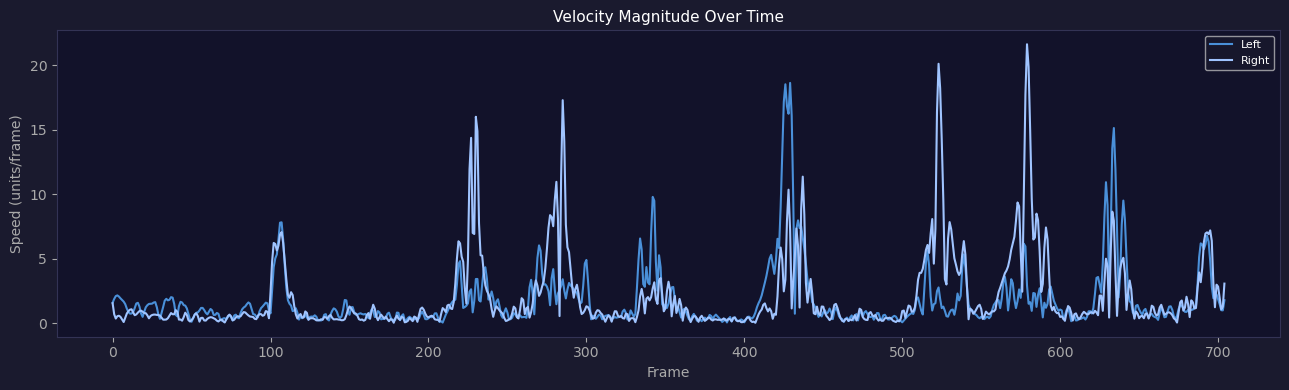

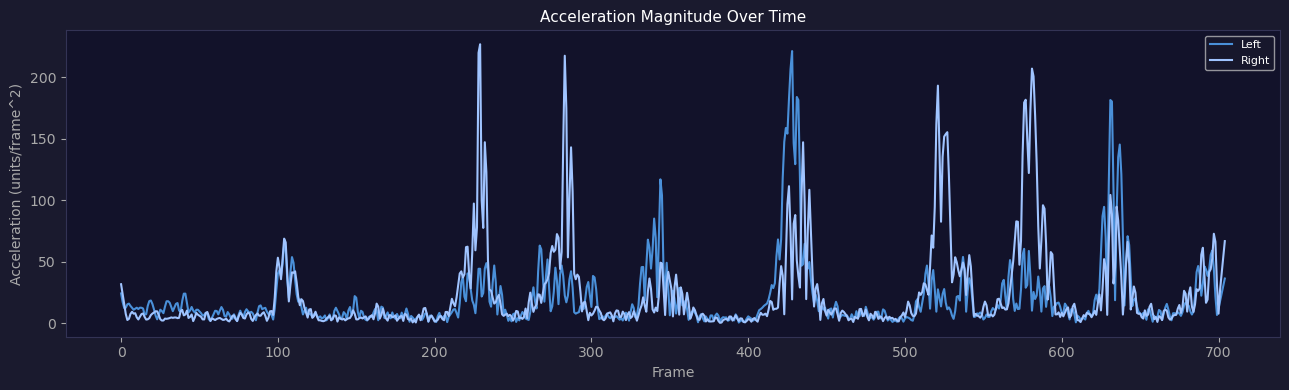

In [8]:
def _plot_mag_time(series, title, ylabel):
    fig, ax = plt.subplots(figsize=(13, 4))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#12122a')
    ax.plot(series[:, 0], color='#4A90D9', linewidth=1.5, label='Left')
    if series.shape[1] > 1:
        ax.plot(series[:, 1], color='#A0C4FF', linewidth=1.5, label='Right')
    ax.set_ylabel(ylabel, color='#aaaaaa')
    ax.set_xlabel('Frame', color='#aaaaaa')
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333355')
    ax.legend(loc='upper right', fontsize=8,
              facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
    ax.set_title(title, color='white', fontsize=11)
    plt.tight_layout()
    plt.show()

if 'velocity_3d' in kin.files:
    vel = np.asarray(kin['velocity_3d'])
    vel_mag = np.linalg.norm(vel, axis=2)
    _plot_mag_time(vel_mag, 'Velocity Magnitude Over Time', 'Speed (units/frame)')
else:
    print('velocity_3d not found in kinematics file.')

if 'acceleration_3d' in kin.files:
    acc = np.asarray(kin['acceleration_3d'])
    acc_mag = np.linalg.norm(acc, axis=2)
    _plot_mag_time(acc_mag, 'Acceleration Magnitude Over Time', 'Acceleration (units/frame^2)')
else:
    print('acceleration_3d not found in kinematics file.')

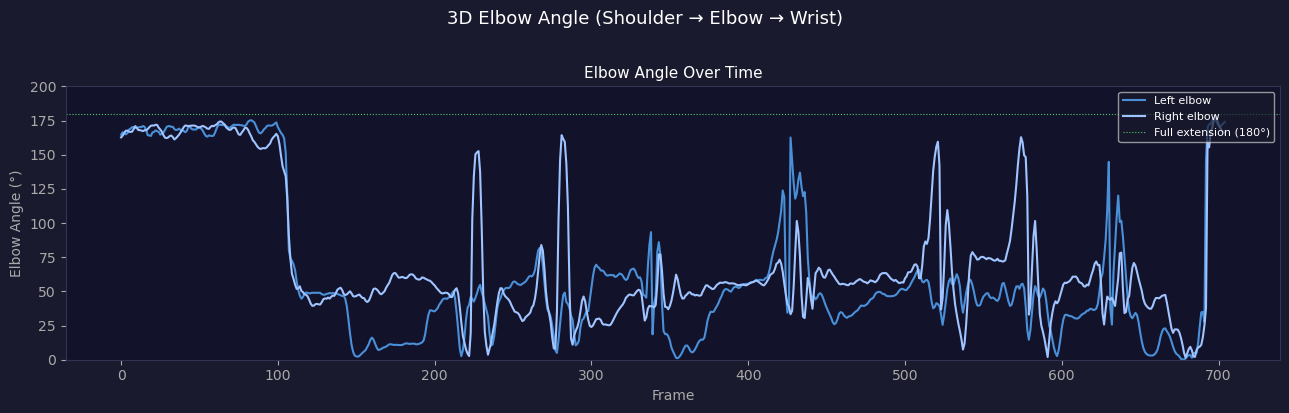

In [9]:
if elbow_angle_deg is None:
    print('Elbow angles not available; check kinematics keys above.')
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#12122a')

    ax.plot(frames, elbow_angle_deg[:, 0], color='#4A90D9', linewidth=1.5, label='Left elbow')
    if elbow_angle_deg.shape[1] > 1:
        ax.plot(frames, elbow_angle_deg[:, 1], color='#A0C4FF', linewidth=1.5, label='Right elbow')
    ax.axhline(180, color='#51CF66', linewidth=0.8, linestyle=':', label='Full extension (180°)')

    ax.set_ylabel('Elbow Angle (°)', color='#aaaaaa')
    ax.set_xlabel('Frame', color='#aaaaaa')
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333355')
    ax.set_ylim(0, 200)
    ax.legend(loc='upper right', fontsize=8,
              facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)
    ax.set_title('Elbow Angle Over Time',
                 color='white', fontsize=11)

    fig.suptitle('3D Elbow Angle (Shoulder → Elbow → Wrist)',
                 color='white', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()